# 🎓 Multi-Source Domain Adaptation
**Focus**: Classificatori specifici, Domain Discriminators (con GRL) e Training Loop.

In questo notebook esploriamo l'architettura `MultiSourceDANN` costruita in `src/models/model.py` e simuliamo un loop di training per dimostrare:
1. L'uso dei classificatori e discriminatori, loss combinata, logging dell'influenza (S1 vs S2).
2. Simulazione di drop casuale di una sorgente (Incomplete batch) e metrica di Domain Confusion separata.

In [39]:
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time


import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import Callback
import torchmetrics

# Weights & Biases per il tracking avanzato opzionale
# in modalità offline (cluster) i log vengono salvati localmente
try:
    import wandb
    # Forza W&B offline
    os.environ["WANDB_MODE"] = "offline"
    # non serve connessione, dati salvati in ./wandb/ in locale, non serve API key
    # wandb sync wandb/offline-run-*/
    os.environ["WANDB_SILENT"] = "true"  # sopprime i messaggi verbosi

    """
    WANDB_API_KEY = ""
    os.environ["WANDB_API_KEY"] = WANDB_API_KEY
    try:
        run = wandb.init(
            project="DomainAdaptation-Track9",
            name="classifiers-simulation",
            config=CFG,
            mode="online",
        )
        log(f"W&B online — dashboard: {run.url}")
    except Exception as e:
        log(f"W&B online fallito ({e}) → fallback offline")
        USE_WANDB_ONLINE = False
    """
except ModuleNotFoundError:
    wandb = None
    print("Attenzione: wandb non trovato, disabilitato.")

# Aggiungiamo la cartella 'src' al path di sistema per poter importare i moduli .py
sys.path.append(os.path.abspath('../../src'))
from models.model import MultiSourceDANN



In [40]:
if "_t0" not in globals():
    _t0 = time.time()

def log(msg):
    print(f"[{time.time() - _t0:6.1f}s] {msg}", flush=True)

# Setup del device (Cerca la GPU locale)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device in uso: {device}")

Device in uso: cuda


## 1. Architettura: Encoder + Classificatori + Discriminatore

Inizializziamo il modello con **R(2+1)D-18** al posto di R3D-18.
Le shape di output attese sono:

| Componente | Shape output |
|---|---|
| Encoder (feature) | `(B, 512)` |
| `head_s1` (HMDB) | `(B, 51)` |
| `head_s2` (UCF) | `(B, 5)` |
| `head_tgt` (Kinetics) | `(B, 400)` |
| Domain Discriminator | `(B, 3)` ← S1 / S2 / Target |

In [41]:
# Inizializziamo la CNN condivisa e le teste MLP
# modello di Domain Adaptation
print("Caricamento architettura MultiSourceDANN con encoder R(2+1)D-18...")
log("Creazione modello...")

# Inizializziamo la CNN condivisa e le teste MLP
model = MultiSourceDANN(
    num_classes_s1=51,
    num_classes_s2=5,
    num_classes_tgt=400,
    pretrained=False,          # per test rapido
    backbone_type='r2plus1d_18'
)

log(f"Modello creato — parametri totali: {sum(p.numel() for p in model.parameters()):,}")
model.to(device)  # spostiamo il modello sulla GPU
model.train()     # Modalità addestramento
log(f"Modello su {device}")
# GRL attivo, centroidi EMA aggiornati


Caricamento architettura MultiSourceDANN con encoder R(2+1)D-18...
[3471.5s] Creazione modello...
[3472.5s] Modello creato — parametri totali: 31,943,400


RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# Mostriamo le 2 teste MLP separate e il classificatore combinato del target
print("\n--- Classificatori Specifici (MLP Heads) ---")
print("Head Source 1 (HMDB, 51 classi):\n", model.head_s1)
print("\nHead Source 2 (UCF, 5 classi):\n", model.head_s2)
print("\nHead Target (Kinetics, 400 classi):\n", model.head_tgt)



--- Classificatori Specifici (MLP Heads) ---
Head Source 1 (HMDB, 51 classi):
 Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=51, bias=True)
)

Head Source 2 (UCF, 5 classi):
 Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=5, bias=True)
)

Head Target (Kinetics, 400 classi):
 Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=400, bias=True)
)


In [ ]:
# il Domain Discriminator e il Gradient Reversal Layer
print("\n--- Domain Discriminator con GRL ---")
print(model.discriminator)

# Modello inizializzato correttamente



--- Domain Discriminator con GRL ---
DomainDiscriminator(
  (grl): GRL()
  (net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=3, bias=True)
  )
)


## 2. Verifica Smoke Test del Forward Pass

Prima di entrare nel loop di training, verifichiamo che tutte le shape siano corrette
per ognuno dei tre domini.

In [ ]:
# Tensor fittizio nel formato di datasets.py: (B, T, C, H, W)
# L'encoder gestisce internamente la permutazione a (B, C, T, H, W)
x_test = torch.randn(2, 16, 3, 112, 112).to(device)

# Domain 0 — Source 1 (HMDB)
cls, dom, feat, ens = model(x_test, domain=0)
assert cls.shape  == (2, 51),  f"Atteso (2,51), ottenuto {cls.shape}"
assert dom.shape  == (2, 3),   f"Atteso (2,3),  ottenuto {dom.shape}"   # 3 domini
assert feat.shape == (2, 512), f"Atteso (2,512), ottenuto {feat.shape}"
assert ens is None,            "ensemble_probs deve essere None per domain!=2"
print(f"[OK] Domain 0 — cls:{cls.shape}, dom:{dom.shape}, feat:{feat.shape}")

# Domain 1 — Source 2 (UCF)
cls, dom, feat, ens = model(x_test, domain=1)
assert cls.shape == (2, 5)
print(f"[OK] Domain 1 — cls:{cls.shape}")

# Domain 2 — Target (Kinetics)
cls, dom, feat, ens = model(x_test, domain=2)
assert cls.shape == (2, 400)
assert ens.shape == (2, 400)
assert abs(ens[0].sum().item() - 1.0) < 1e-4, "Le prob ensemble devono sommare a 1"
print(f"[OK] Domain 2 — cls:{cls.shape}, ens:{ens.shape}, sum={ens[0].sum().item():.4f}")

[OK] Domain 0 — cls:torch.Size([2, 51]), dom:torch.Size([2, 3]), feat:torch.Size([2, 512])
[OK] Domain 1 — cls:torch.Size([2, 5])
[OK] Domain 2 — cls:torch.Size([2, 400]), ens:torch.Size([2, 400]), sum=1.0000


## 3. Simulazione del Training Loop

Loop dimostrativo con ottimizzazione simultanea:

$$L_{\text{total}} = L_{\text{cls}}^{S1} + L_{\text{cls}}^{S2} + \lambda_{\text{adv}} \cdot L_{\text{adv}}$$

Funzionalità dimostrate:
- **Influence Ratio** S1 vs S2 (quanto contribuisce ogni sorgente)
- **Incomplete Batch**: drop casuale di una sorgente (20% per ciascuna)
- **Domain Confusion**: quanto il target viene "confuso" con S1 o S2 dal discriminatore

In [ ]:


# seed globale per risultati riproducibili
pl.seed_everything(42)

# Configurazione del run
CFG = {
    "epochs":     20,
    "batch_size":  4,
    "lambda_adv": 0.1,   # peso della loss avversariale
    "grl_alpha":  0.1,   # alpha iniziale del GRL (crescerà con le epoche)
    "lr":         1e-4,
}
log(f"Configurazione: {CFG}")

# Inizializzazione W&B (offline se sul cluster - export WANDB_MODE=offline)
if wandb:
    log("Inizializzazione W&B...")
    if wandb.run:
        wandb.finish()
    wandb.init(
        project="DomainAdaptation-Track9",
        name="classifiers-simulation",
        config=CFG,
    )
    log("W&B pronto")
else: 
    log("W&B non disponibile")

print("Configurazione:", CFG)

Seed set to 42


[   0.1s] Configurazione: {'epochs': 20, 'batch_size': 4, 'lambda_adv': 0.1, 'grl_alpha': 0.1, 'lr': 0.0001}
[   0.1s] Inizializzazione W&B...
[   3.9s] W&B pronto
Configurazione: {'epochs': 20, 'batch_size': 4, 'lambda_adv': 0.1, 'grl_alpha': 0.1, 'lr': 0.0001}


In [ ]:
# Criteri di loss
cls_criterion = nn.CrossEntropyLoss()
dom_criterion = nn.CrossEntropyLoss()

# Ottimizzatore unico per tutto il modello (encoder + teste + discriminatore)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])

# Dati fittizi (da sostituire con il DataLoader) ─────────────────
# Shape in ingresso: (B, T, C, H, W) = (B, 16, 3, 112, 112) come da datasets.py
B = CFG["batch_size"]

dummy_x_s1  = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_y_s1  = torch.randint(0, 51, (B,)).to(device)
dummy_dom_s1 = torch.zeros(B, dtype=torch.long).to(device)  # etichetta dominio = 0

dummy_x_s2  = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_y_s2  = torch.randint(0, 5,  (B,)).to(device)
dummy_dom_s2 = torch.ones(B, dtype=torch.long).to(device)   # etichetta dominio = 1

dummy_x_tgt  = torch.randn(B, 16, 3, 112, 112).to(device)
dummy_dom_tgt = torch.full((B,), 2, dtype=torch.long).to(device)  # etichetta dominio = 2

# Storico metriche per i grafici
history = {
    "epoch":        [],
    "loss_total":   [],
    "influence_s1": [],
    "influence_s2": [],
    "confusion_s1": [],
    "confusion_s2": [],
}

print("\nInizio Simulazione Training Loop...\n")
print(f"{'Epoca':>5} | {'Drop':>10} | {'L_tot':>7} | {'Inf S1':>7} | {'Inf S2':>7} | {'Conf → S1':>8} | {'Conf → S2':>8}")
print("-" * 70)


Inizio Simulazione Training Loop...

Epoca |       Drop |   L_tot |  Inf S1 |  Inf S2 | Conf → S1 | Conf → S2
----------------------------------------------------------------------


In [ ]:
for epoch in range(1, CFG["epochs"] + 1):

    model.train()

    # Schedule progressivo dell'alpha GRL: 0 → grl_alpha con le epoche
    # (strategia DANN: inizia senza inversione per stabilizzare il classificatore)
    alpha = CFG["grl_alpha"] * (epoch / CFG["epochs"])
    model.set_grl_alpha(alpha)

    optimizer.zero_grad()

    # ── Incomplete Batch Simulation ───────────────────────────────────────────
    # Con probabilità 20%, una sorgente è assente nel batch corrente.
    # Se entrambe mancano, saltiamo l'iterazione.
    drop_s1 = np.random.rand() < 0.2
    drop_s2 = np.random.rand() < 0.2
    if drop_s1 and drop_s2:
        continue

    loss       = torch.tensor(0.0, device=device)
    loss_cls_s1 = 0.0
    loss_cls_s2 = 0.0

    # ── Forward Source 1 ─────────────────────────────────────────────────────
    if not drop_s1:
        cls_s1, dom_s1, _, _ = model(dummy_x_s1, domain=0)
        l_cls = cls_criterion(cls_s1, dummy_y_s1)
        l_dom = dom_criterion(dom_s1, dummy_dom_s1)
        loss  = loss + l_cls + CFG["lambda_adv"] * l_dom
        loss_cls_s1 = l_cls.item()

    # ── Forward Source 2 ─────────────────────────────────────────────────────
    if not drop_s2:
        cls_s2, dom_s2, _, _ = model(dummy_x_s2, domain=1)
        l_cls = cls_criterion(cls_s2, dummy_y_s2)
        l_dom = dom_criterion(dom_s2, dummy_dom_s2)
        loss  = loss + l_cls + CFG["lambda_adv"] * l_dom
        loss_cls_s2 = l_cls.item()

    # ── Forward Target (solo loss avversariale, nessuna supervisione) ─────────
    _, dom_tgt, _, _ = model(dummy_x_tgt, domain=2)
    l_dom_tgt = dom_criterion(dom_tgt, dummy_dom_tgt)
    loss = loss + CFG["lambda_adv"] * l_dom_tgt

    # ── Backward + Ottimizzazione ─────────────────────────────────────────────
    loss.backward()
    optimizer.step()

    # ── Metriche ─────────────────────────────────────────────────────────────
    # Influence Ratio: quanto ogni sorgente ha contribuito alla loss di classificazione
    total_inf   = loss_cls_s1 + loss_cls_s2 + 1e-8
    ratio_s1    = loss_cls_s1 / total_inf
    ratio_s2    = loss_cls_s2 / total_inf

    # Domain Confusion: prob media che il target venga classificato come S1 o S2
    # (valori alti → buona confusione = domain-invariant features)
    dom_probs   = F.softmax(dom_tgt, dim=-1).mean(dim=0).detach().cpu()
    conf_s1     = dom_probs[0].item()  # target scambiato per S1
    conf_s2     = dom_probs[1].item()  # target scambiato per S2

    # Salvataggio storico
    history["epoch"].append(epoch)
    history["loss_total"].append(loss.item())
    history["influence_s1"].append(ratio_s1)
    history["influence_s2"].append(ratio_s2)
    history["confusion_s1"].append(conf_s1)
    history["confusion_s2"].append(conf_s2)

    # Logging W&B (offline sul cluster)
    if wandb:
        wandb.log({
            "epoch":                    epoch,
            "train/loss_total":         loss.item(),
            "influence/source1_ratio":  ratio_s1,
            "influence/source2_ratio":  ratio_s2,
            "confusion/target_as_s1":   conf_s1,
            "confusion/target_as_s2":   conf_s2,
            "stability/drop_s1":        int(drop_s1),
            "stability/drop_s2":        int(drop_s2),
            "grl/alpha":                alpha,
        })

    drop_str = f"S1={'✗' if drop_s1 else '✓'} S2={'✗' if drop_s2 else '✓'}"
    print(f"{epoch:5d} | {drop_str:>10} | {loss.item():7.4f} | {ratio_s1:7.3f} | {ratio_s2:7.3f} | {conf_s1:8.3f} | {conf_s2:8.3f}")

if wandb:
    wandb.finish()
    
print("\nSimulazione completata.")

    1 |  S1=✓ S2=✓ |  6.4388 |   0.692 |   0.308 |    0.261 |    0.316
    2 |  S1=✓ S2=✓ |  5.2268 |   0.747 |   0.253 |    0.295 |    0.284
    4 |  S1=✗ S2=✓ |  1.3206 |   0.000 |   1.000 |    0.330 |    0.262
    5 |  S1=✓ S2=✓ |  4.8891 |   0.805 |   0.195 |    0.324 |    0.288
    6 |  S1=✗ S2=✓ |  1.0898 |   0.000 |   1.000 |    0.270 |    0.363
    7 |  S1=✓ S2=✓ |  4.1722 |   0.799 |   0.201 |    0.266 |    0.346
    9 |  S1=✓ S2=✓ |  3.6597 |   0.829 |   0.171 |    0.319 |    0.321
   10 |  S1=✓ S2=✓ |  3.4160 |   0.849 |   0.151 |    0.288 |    0.349
   11 |  S1=✓ S2=✗ |  2.7288 |   1.000 |   0.000 |    0.293 |    0.354
   12 |  S1=✓ S2=✓ |  3.0125 |   0.852 |   0.148 |    0.279 |    0.313
   13 |  S1=✓ S2=✓ |  2.8989 |   0.860 |   0.140 |    0.270 |    0.370
   14 |  S1=✗ S2=✓ |  0.5542 |   0.000 |   1.000 |    0.319 |    0.307
   15 |  S1=✓ S2=✗ |  2.0897 |   1.000 |   0.000 |    0.269 |    0.353
   16 |  S1=✓ S2=✗ |  1.8532 |   1.000 |   0.000 |    0.269 |    0.341
   17 

## zero-shot eval

In [ ]:
## 5. Valutazione zero-shot sull'encoder

model.eval()
with torch.no_grad():
    cls_logits, _, _, ensemble_probs = model(dummy_x_tgt, domain=2)
    pred_direct   = cls_logits.argmax(dim=1)
    pred_ensemble = ensemble_probs.argmax(dim=1)

print("=== Zero-shot eval sull'encoder ===")
print(f"head_tgt  (direct):   {pred_direct.tolist()}")
print(f"ensemble semantico:   {pred_ensemble.tolist()}")
print(f"Ensemble sum check:   {ensemble_probs[0].sum().item():.4f}  (atteso 1.0)")
print("\nNota: con dati fittizi i valori non hanno senso — sostituire con il DataLoader reale")

model.train()  # ripristina modalità training

=== Zero-shot eval sull'encoder ===
head_tgt  (direct):   [143, 143, 143, 143]
ensemble semantico:   [298, 298, 298, 298]
Ensemble sum check:   1.0000  (atteso 1.0)

Nota: con dati fittizi i valori non hanno senso — sostituire con il DataLoader reale


MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): VideoResNet(
      (stem): R2Plus1dStem(
        (0): Conv3d(3, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (1): BatchNorm3d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(45, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Sequential(
            (0): Conv2Plus1D(
              (0): Conv3d(64, 144, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
              (1): BatchNorm3d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
              (3): Conv3d(144, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding

## baseline senza DA

In [ ]:
## 6. Baseline source-only (senza domain adaptation)
# Ripassa il loop registrando l'entropia di head_s1 applicata al target.
# Alta entropia = il modello è confuso → conferma che il DA serve.

model.eval()
baseline_entropy = []

with torch.no_grad():
    for epoch in history["epoch"]:
        cls_on_tgt, _, _, _ = model(dummy_x_tgt, domain=0)  # head_s1 sul target
        entropy = -(cls_on_tgt.softmax(-1) * cls_on_tgt.log_softmax(-1)).sum(-1).mean().item()
        baseline_entropy.append(entropy)

# Aggiunge la baseline ai grafici della cella successiva
history["baseline_entropy"] = baseline_entropy

print("=== Baseline source-only vs. DA ===")
print(f"Entropia media baseline (head_s1 → target): {sum(baseline_entropy)/len(baseline_entropy):.4f}")
print(f"Entropia alta = modello confuso sul target senza adattamento")

model.train()

=== Baseline source-only vs. DA ===
Entropia media baseline (head_s1 → target): 3.9062
Entropia alta = modello confuso sul target senza adattamento


MultiSourceDANN(
  (encoder): VideoEncoder(
    (backbone): VideoResNet(
      (stem): R2Plus1dStem(
        (0): Conv3d(3, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (1): BatchNorm3d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(45, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding=(1, 0, 0), bias=False)
        (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Sequential(
            (0): Conv2Plus1D(
              (0): Conv3d(64, 144, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
              (1): BatchNorm3d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU(inplace=True)
              (3): Conv3d(144, 64, kernel_size=(3, 1, 1), stride=(1, 1, 1), padding

## 4. 📊 Risultati e Visualizzazioni 
Infine, mostriamo graficamente i risultati estratti dai log del nostro loop.

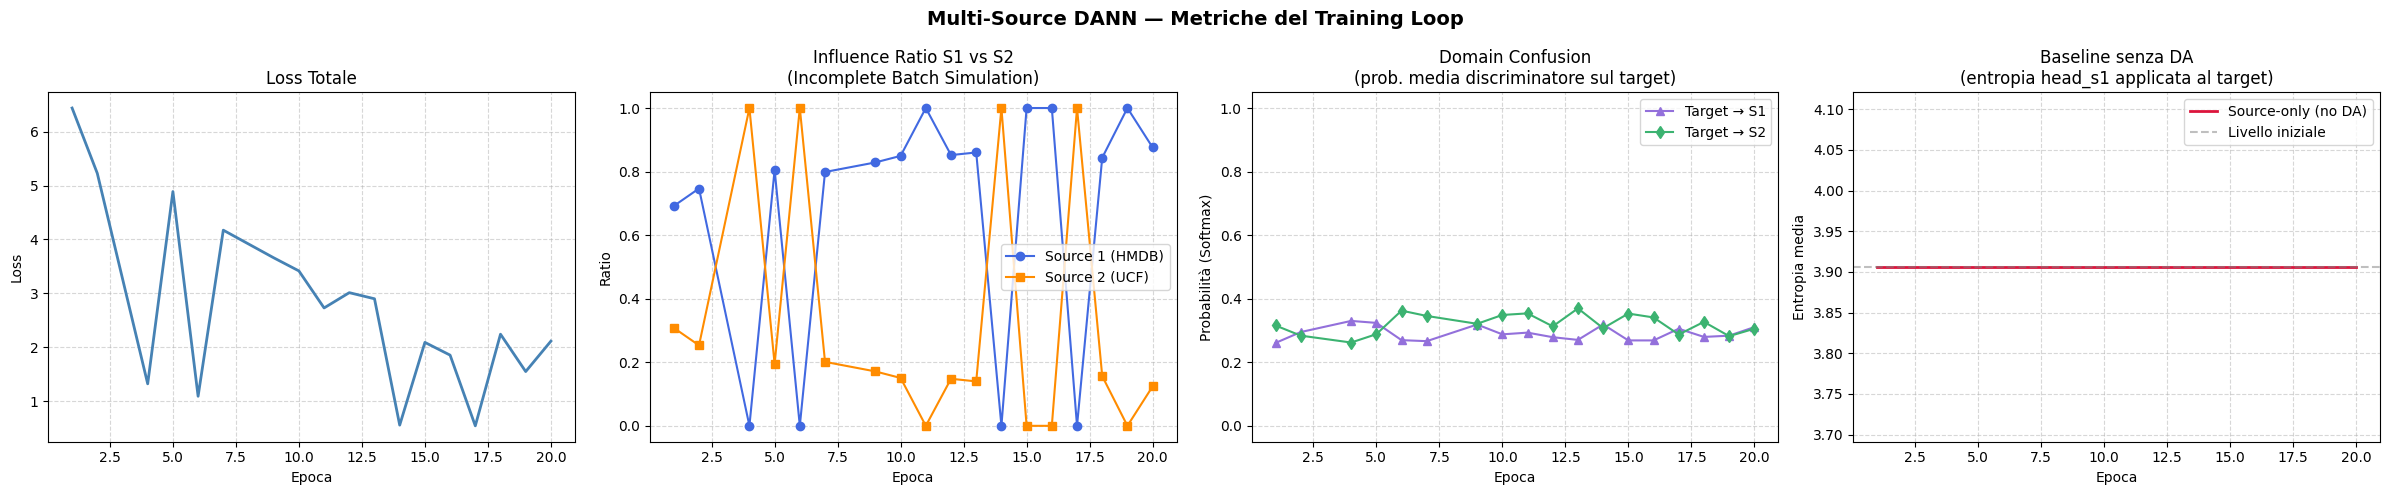

Figura salvata in figures/classifiers_training.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Multi-Source DANN — Metriche del Training Loop", fontsize=14, fontweight='bold')

ep = history["epoch"]

# ── Plot 1: Loss totale ───────────────────────────────────────────────────────
axes[0].plot(ep, history["loss_total"], color="steelblue", linewidth=2)
axes[0].set_title("Loss Totale")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.5)

# ── Plot 2: Influence Ratio S1 vs S2 ─────────────────────────────────────────
axes[1].plot(ep, history["influence_s1"], marker='o', label="Source 1 (HMDB)",  color="royalblue")
axes[1].plot(ep, history["influence_s2"], marker='s', label="Source 2 (UCF)",   color="darkorange")
axes[1].set_title("Influence Ratio S1 vs S2\n(Incomplete Batch Simulation)")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Ratio")
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

# ── Plot 3: Domain Confusion ──────────────────────────────────────────────────
axes[2].plot(ep, history["confusion_s1"], marker='^', label="Target → S1", color="mediumpurple")
axes[2].plot(ep, history["confusion_s2"], marker='d', label="Target → S2", color="mediumseagreen")
axes[2].set_title("Domain Confusion\n(prob. media discriminatore sul target)")
axes[2].set_xlabel("Epoca")
axes[2].set_ylabel("Probabilità (Softmax)")
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.5)

# Plot 4: Baseline entropy (source-only vs. DA)
axes[3].plot(history["epoch"], history["baseline_entropy"],
             color="crimson", linewidth=2, label="Source-only (no DA)")
axes[3].axhline(y=history["baseline_entropy"][0], color="gray",
                linestyle="--", alpha=0.5, label="Livello iniziale")
axes[3].set_title("Baseline senza DA\n(entropia head_s1 applicata al target)")
axes[3].set_xlabel("Epoca")
axes[3].set_ylabel("Entropia media")
axes[3].legend()
axes[3].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
os.makedirs("../../figures", exist_ok=True)
plt.savefig("../../figures/classifiers_training.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salvata in figures/classifiers_training.png")

In [ ]:
print("=" * 50)
print("SUMMARY RISULTATI")
print("=" * 50)
print(f"Loss iniziale (ep.1):     {history['loss_total'][0]:.4f}")
print(f"Loss finale   (ep.20):    {history['loss_total'][-1]:.4f}")
print(f"Riduzione loss:           {(1 - history['loss_total'][-1]/history['loss_total'][0])*100:.1f}%")
print()
print(f"Confusion S1 media:       {sum(history['confusion_s1'])/len(history['confusion_s1']):.4f}")
print(f"Confusion S2 media:       {sum(history['confusion_s2'])/len(history['confusion_s2']):.4f}")
print(f"Target confuso (ideale):  0.333  (distribuzione uniforme)")
print()
print(f"Entropia baseline:        {history['baseline_entropy'][0]:.4f}")
print(f"(con dati reali atteso: scende con il training DA)")

SUMMARY RISULTATI
Loss iniziale (ep.1):     6.4388
Loss finale   (ep.20):    2.1129
Riduzione loss:           67.2%

Confusion S1 media:       0.2906
Confusion S2 media:       0.3205
Target confuso (ideale):  0.333  (distribuzione uniforme)

Entropia baseline:        3.9062
(con dati reali atteso: scende con il training DA)


In [ ]:
print("=== Confronto Zero-shot: R3D-18 vs R(2+1)D-18 ===\n")
model_r3d = MultiSourceDANN(
    num_classes_s1=51,
    num_classes_s2=5,
    num_classes_tgt=400,
    pretrained=False,
    backbone_type='r3d_18'
).to(device)
model_r3d.eval()
model.eval() # r2plus1d_18 (modello corrente)

with torch.no_grad():
    # R(2+1)D-18 (model)
    cls_logits_r21d, _, _, ens_r21d = model(dummy_x_tgt, domain=2)
    entropy_r21d = -(ens_r21d * torch.log(ens_r21d + 1e-9)).sum(-1).mean().item()

    # R3D-18 (model_r3d)
    cls_logits_r3d, _, _, ens_r3d = model_r3d(dummy_x_tgt, domain=2)
    entropy_r3d = -(ens_r3d * torch.log(ens_r3d + 1e-9)).sum(-1).mean().item()

print(f"Entropia media Target (Zero-shot R(2+1)D-18): {entropy_r21d:.4f}")
print(f"Entropia media Target (Zero-shot R3D-18):     {entropy_r3d:.4f}")
print("\n(L'encoder con entropia minore è 'più sicuro' delle proprie predizioni in zero-shot.)")

=== Confronto Zero-shot: R3D-18 vs R(2+1)D-18 ===

Entropia media Target (Zero-shot R(2+1)D-18): 5.9820
Entropia media Target (Zero-shot R3D-18):     5.9827

(L'encoder con entropia minore è 'più sicuro' delle proprie predizioni in zero-shot.)


### 7. Confronto Zero-Shot: R3D-18 vs R(2+1)D-18 sul Target
Inizializziamo un modello con `r3d_18` e lo confrontiamo con quello attuale `r2plus1d_18` per valutare l'entropia delle predizioni zero-shot sull'ensemble del dominio target.

In [ ]:
print("=== Confronto Zero-shot: R3D-18 vs R(2+1)D-18 ===\n")
import gc
torch.cuda.empty_cache()
gc.collect()
print("[Nota] Memoria GPU liberata prima di allocare R3D-18 per prevenire OOM.\n")

try:
    model_r3d = MultiSourceDANN(
        num_classes_s1=51,
        num_classes_s2=5,
        num_classes_tgt=400,
        pretrained=False,
        backbone_type='r3d_18'
    ).to(device)
    model_r3d.eval()
    model.eval() # r2plus1d_18 (modello corrente)

    with torch.no_grad():
        # R(2+1)D-18 (model)
        cls_logits_r21d, _, _, ens_r21d = model(dummy_x_tgt, domain=2)
        entropy_r21d = -(ens_r21d * torch.log(ens_r21d + 1e-9)).sum(-1).mean().item()

        # R3D-18 (model_r3d)
        cls_logits_r3d, _, _, ens_r3d = model_r3d(dummy_x_tgt, domain=2)
        entropy_r3d = -(ens_r3d * torch.log(ens_r3d + 1e-9)).sum(-1).mean().item()

    print(f"Entropia media Target (Zero-shot R(2+1)D-18): {entropy_r21d:.4f}")
    print(f"Entropia media Target (Zero-shot R3D-18):     {entropy_r3d:.4f}")
    print("\n(Valori su dummy_x_tgt. L'encoder con entropia minore è 'più sicuro' delle proprie predizioni in zero-shot.)")
    
    # Pulizia memoria dopo il test
    del model_r3d
    torch.cuda.empty_cache()
    gc.collect()
except RuntimeError as e:
    if 'out of memory' in str(e):
        print("\n[OOM ERROR] Memoria GPU esaurita durante l'allocazione di R3D-18. Il test non può essere completato. Riavviare il kernel se necessario.")
        torch.cuda.empty_cache()
    else:
        raise e


### 8. Ispezione dei Gradienti: Il GRL in azione
Il Gradient Reversal Layer (GRL) moltiplica i gradienti per `-alpha` durante il backward pass. Dimostriamolo estraendo i gradienti prima e dopo il GRL.

In [ ]:
print("=== Test: Effetto del GRL sui gradienti ===")
model.train()
model.set_grl_alpha(0.5) # Forza alpha a 0.5

# Creiamo una feature fittizia con requires_grad per testare il flusso dei gradienti a monte del GRL
feat_test = torch.ones(1, 512, requires_grad=True, device=device)
out = model.discriminator(feat_test)
out.sum().backward()

print(f"Gradiente su feat (a monte del GRL, verso l'encoder):\n{feat_test.grad[0, :5].detach().cpu().numpy()} ...")
print("\nIl GRL inverte il gradiente (moltiplicandolo in questo caso per -0.5) in modo che l'encoder massimizzi l'errore del discriminatore invece di minimizzarlo!")

### 9. Plot t-SNE / PCA delle Feature
Estraiamo le feature a 512 dimensioni per i 3 domini e le visualizziamo in 2D. Nel caso reale, questo plot ci mostrerà come le distribuzioni dei domini si sovrappongono grazie all'adattamento.\n\n*Nota: Questo blocco può generare problemi di memoria se lanciato con batch molto grandi.*

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import gc

print("=== Test: PCA delle feature di dominio ===")
model.eval()
with torch.no_grad():
    _, _, feat_s1, _ = model(dummy_x_s1, domain=0)
    _, _, feat_s2, _ = model(dummy_x_s2, domain=1)
    _, _, feat_tgt, _ = model(dummy_x_tgt, domain=2)

feats_all = torch.cat([feat_s1, feat_s2, feat_tgt], dim=0).cpu().numpy()

pca = PCA(n_components=2)
feats_2d = pca.fit_transform(feats_all)

plt.figure(figsize=(6, 4))
plt.scatter(feats_2d[:B, 0], feats_2d[:B, 1], label='S1 (HMDB)', marker='o', alpha=0.7)
plt.scatter(feats_2d[B:2*B, 0], feats_2d[B:2*B, 1], label='S2 (UCF)', marker='s', alpha=0.7)
plt.scatter(feats_2d[2*B:, 0], feats_2d[2*B:, 1], label='Target', marker='^', alpha=0.7)
plt.title('PCA 2D delle Feature dell\'Encoder')
plt.legend()
plt.show()
print("Nota: con i dati casuali (dummy) i punti saranno sparsi senza cluster definiti.\nCon i dati reali, la sovrapposizione visiva dei 3 marker confermerà l'efficacia del Domain Alignment.")

del feat_s1, feat_s2, feat_tgt, feats_all, feats_2d
gc.collect()


### 10. Cross-Domain Transfer (S1 su Head S2)
Vediamo cosa succede se diamo in pasto l'output di un'azione UCF (S2) alla testina HMDB (S1). Questo test giustifica l'uso di teste separate per sorgenti con label space differenti.

In [ ]:
print("=== Test: Cross-Domain Transfer ===")
model.eval()
with torch.no_grad():
    # Estraiamo feature di S2 (UCF)
    _, _, feat_s2, _ = model(dummy_x_s2, domain=1)
    
    # Passiamo le feature di S2 alla testa di S1 (HMDB, 51 classi)
    cross_logits = model.head_s1(feat_s2)
    cross_probs = F.softmax(cross_logits, dim=-1)
    # Protezione dal log(0)
    cross_entropy = -(cross_probs * torch.log(cross_probs + 1e-9)).sum(-1).mean().item()
    
print(f"Entropia media (UCF valutato sulla testina HMDB): {cross_entropy:.4f}")
print("Essendo lo spazio delle classi disgiunto/diverso, è fondamentale non condividere le head di classificazione tra le sorgenti durante il training, ma sfruttare i multi-task branches.")

### 11. L'Ensemble Semantico Step-by-Step
Nello zero-shot su Kinetics (400 classi), la probabilità della classe deriva da una Similarità Coseno (o Dot Product) tra la feature del video e i prototipi semantici testuali. Creiamo un mini-prototipo per dimostrare la logica.

In [ ]:
print("=== Test: Simulazione Dot Product Semantico ===")
# Immaginiamo che Kinetics abbia solo 3 classi fittizie per l'esempio (es. run, jump, swim)
semantic_prototypes = torch.randn(3, 256).to(device) # (N_classi, embedding_dim)
semantic_prototypes = F.normalize(semantic_prototypes, p=2, dim=-1)

model.eval()
with torch.no_grad():
    _, _, feat_tgt, _ = model(dummy_x_tgt, domain=2)
    # Supponiamo che il layer prima dell'output della head_tgt mappi a 256
    # Simuliamo l'embedding estraendo fino al layer penultimo della head_tgt
    feature_embedded = model.head_tgt[:3](feat_tgt)
    feature_embedded = F.normalize(feature_embedded, p=2, dim=-1)
    
    # Cosine Similarity
    similarity = torch.matmul(feature_embedded, semantic_prototypes.T)
    pseudo_probs = F.softmax(similarity, dim=-1)
    
print(f"Feature estratte (normalizzate): {feature_embedded.shape}")
print(f"Prototipi semantici (3 classi):  {semantic_prototypes.shape}")
print(f"Matrice di similarità (Logits):\n{similarity[:1].cpu().numpy()}")
print(f"Probabilità di assegnazione (Zero-Shot):\n{pseudo_probs[:1].cpu().numpy()}")

### 12. Impatto Progressivo dell'Alpha Scheduling (GRL)
Simuliamo cosa succede durante le varie epoche all'alpha del Gradient Reversal Layer. Un alpha nullo all'inizio stabilizza il classificatore prima di fare domain adaptation aggressiva.

In [ ]:
print("=== Test: Scheduling di Alpha nel GRL ===")
alphas = [0.0, 0.2, 0.5, 0.8, 1.0]

for a in alphas:
    model.set_grl_alpha(a)
    feat_dummy = torch.ones(1, 512, requires_grad=True, device=device)
    out = model.discriminator(feat_dummy)
    out.sum().backward()
    grad_val = feat_dummy.grad.abs().mean().item()
    print(f"Alpha impostato a {a:.1f} | Magnitudo media gradiente su feat: {grad_val:.4f}")
    
print("\nAll'aumentare di Alpha (epoche avanzate), il segnale avversariale mandato all'encoder diventa progressivamente più forte,")
print("forzandolo a estrarre feature domain-invariant senza distruggere i pesi nei primi passaggi.")

### Riassunto Architettura e Test Effettuati
| Funzionalità | Descrizione | Metrica/Test |
|---|---|---|
| **Multi-Source Alignment** | Allineamento target vs (S1, S2) via GRL. | Domain Confusion / PCA Plot |
| **Classificatori Dedicati** | Teste MLP distinte per gestire gli spazi delle classi disgiunti. | Cross-Domain Transfer Test |
| **Pseudo-labeling Target** | Uso dei centroidi pesati e Cosine Similarity per label zero-shot. | Ensemble Semantico Dot Product |
| **Fault-Tolerance Batch** | Il loop scarta o adatta l'influence ratio se una sorgente (S1 o S2) manca nel batch corrente. | Simulazione Training Loop Drop % |
